In [1]:
import os
import cv2
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    BatchNormalization,
    GlobalAveragePooling2D,
    Dense,
    Dropout
)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Fix randomness (important for results consistency)
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

In [2]:
STUDENT_NAME = "Sara"
TARGET_CLASSES = ['basketball', 'biking', 'tennis_swing']

# Image settings
IMG_HEIGHT = 64
IMG_WIDTH = 64

# Limit frames per class (to control training time)
MAX_FRAMES_PER_CLASS = 8000

NUM_CLASSES = len(TARGET_CLASSES)

print("Student:", STUDENT_NAME)
print("Classes:", TARGET_CLASSES)

Student: Sara
Classes: ['basketball', 'biking', 'tennis_swing']


In [5]:
from google.colab import drive
import os

# 1. Mount your Google Drive storage layers
drive.mount('/content/drive')

# 2. Change the active terminal directory directly into your project folder
# (Since your 'cv' folder sits in your main Drive space, this path targets it perfectly)
os.chdir('/content/drive/MyDrive/cv')

print("Current working directory is now:", os.getcwd())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Current working directory is now: /content/drive/MyDrive/cv


In [6]:
import os

print("--- Checking files in your current working directory ---")
if os.path.exists('dataset'):
    print("Found 'dataset' folder! Its contents are:")
    print(os.listdir('dataset'))
else:
    print("No 'dataset' folder found here. Top-level files are:")
    print(os.listdir('.'))

--- Checking files in your current working directory ---
Found 'dataset' folder! Its contents are:
['basketball', 'biking', 'diving', 'tennis_swing', 'trampoline_jumping', 'soccer_juggling', 'golf_swing', 'horse_riding', 'volleyball_spiking', 'walking', 'readme.txt', 'swing']


In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:
import os

DATASET_DIR = "dataset"

if not os.path.exists(DATASET_DIR):
    DATASET_DIR = "dataset"

print("Dataset path used:", DATASET_DIR)

available_classes = sorted(os.listdir(DATASET_DIR))

print("=" * 50)
print("Available Classes:")
for cls in available_classes:
    print("-", cls)
print("=" * 50)

missing_classes = []

for cls in TARGET_CLASSES:
    if cls not in available_classes:
        missing_classes.append(cls)

if len(missing_classes) == 0:
    print("All target classes found ")
else:
    print("Missing classes :", missing_classes)

Dataset path used: dataset
Available Classes:
- basketball
- biking
- diving
- golf_swing
- horse_riding
- readme.txt
- soccer_juggling
- swing
- tennis_swing
- trampoline_jumping
- volleyball_spiking
- walking
All target classes found 


In [11]:
def extract_frames(video_path):
    frames = []
    cap = cv2.VideoCapture(video_path)

    while cap.isOpened():
        success, frame = cap.read()

        if not success:
            break

        frame = cv2.resize(frame, (IMG_WIDTH, IMG_HEIGHT))
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frame = frame / 255.0

        frames.append(frame)

    cap.release()
    return frames

def build_dataset():
    X = []
    y = []

    print("Processing dataset...")

    for label, class_name in enumerate(TARGET_CLASSES):
        class_path = os.path.join(DATASET_DIR, class_name)

        all_frames = []

        for root, _, files in os.walk(class_path):
            for file in files:
                if file.endswith((".mpg", ".avi", ".mp4")):
                    video_path = os.path.join(root, file)

                    frames = extract_frames(video_path)
                    all_frames.extend(frames)

        print(f"{class_name}: total frames = {len(all_frames)}")

        selected_frames = random.sample(
            all_frames,
            min(len(all_frames), MAX_FRAMES_PER_CLASS)
        )

        X.extend(selected_frames)
        y.extend([label] * len(selected_frames))

    X = np.array(X, dtype="float32")
    y = np.array(y)

    # Shuffle
    indices = np.arange(len(X))
    np.random.shuffle(indices)

    X = X[indices]
    y = y[indices]

    return X, y

X, y = build_dataset()

# One-hot encoding
y = to_categorical(y, NUM_CLASSES)

print("Final shapes:")
print("X:", X.shape)
print("y:", y.shape)

Processing dataset...
basketball: total frames = 15092
biking: total frames = 25272
tennis_swing: total frames = 24096
Final shapes:
X: (24000, 64, 64, 3)
y: (24000, 3)


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    shuffle=True,
    stratify=np.argmax(y, axis=1),
    random_state=SEED
)

print("=" * 45)
print("Dataset Split Summary")
print("=" * 45)
print(f"Training samples: {len(X_train):,}")
print(f"Testing samples : {len(X_test):,}")
print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("=" * 45)

Dataset Split Summary
Training samples: 19,200
Testing samples : 4,800
X_train shape: (19200, 64, 64, 3)
X_test shape : (4800, 64, 64, 3)


In [13]:
def create_cnn_model():
    model = Sequential([
        Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)),

        Conv2D(32, (3, 3), activation="relu", padding="same"),
        BatchNormalization(),
        MaxPooling2D((2, 2)),

        Conv2D(64, (3, 3), activation="relu", padding="same"),
        BatchNormalization(),
        MaxPooling2D((2, 2)),

        Conv2D(128, (3, 3), activation="relu", padding="same"),
        BatchNormalization(),
        MaxPooling2D((2, 2)),

        GlobalAveragePooling2D(),

        Dense(128, activation="relu"),
        Dropout(0.4),

        Dense(NUM_CLASSES, activation="softmax")
    ])

    return model


model = create_cnn_model()

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,043 (433.76 KB)

 Trainable params: 110,595 (432.01 KB)

 Non-trainable params: 448 (1.75 KB)

In [15]:
checkpoint = ModelCheckpoint(
    "Sara's_best_action_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=6,
    restore_best_weights=True,
    verbose=1
)

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    X_train,
    y_train,
    epochs=15,
    batch_size=16,
    validation_split=0.2,
    shuffle=True,
    callbacks=[checkpoint, early_stop]
)

Epoch 1/15
959/960 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7942 - loss: 0.4844
Epoch 1: val_accuracy improved from None to 0.81797, saving model to Sara's_best_action_model.keras

Epoch 1: finished saving model to Sara's_best_action_model.keras
960/960 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.8979 - loss: 0.2661 - val_accuracy: 0.8180 - val_loss: 0.4868
Epoch 2/15
957/960 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9780 - loss: 0.0657
Epoch 2: val_accuracy improved from 0.81797 to 0.91771, saving model to Sara's_best_action_model.keras

Epoch 2: finished saving model to Sara's_best_action_model.keras
960/960 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9807 - loss: 0.0577 - val_accuracy: 0.9177 - val_loss: 0.2163
Epoch 3/15
949/960 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9825 - loss: 0.0537
Epoch 3: val_accuracy did not improve from 0.91771
960/960 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9876 - loss: 0.0384 - val_accuracy: 0.8562 - val_loss: 0.4447
Epoc

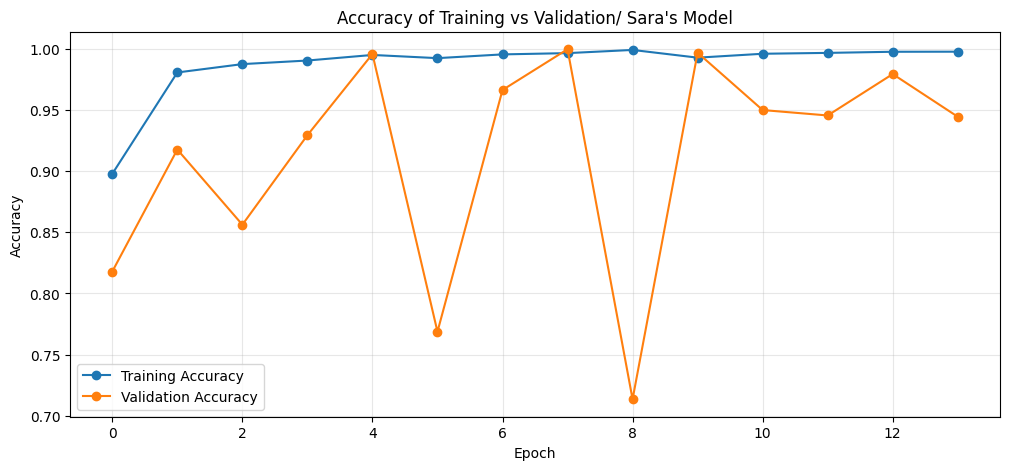

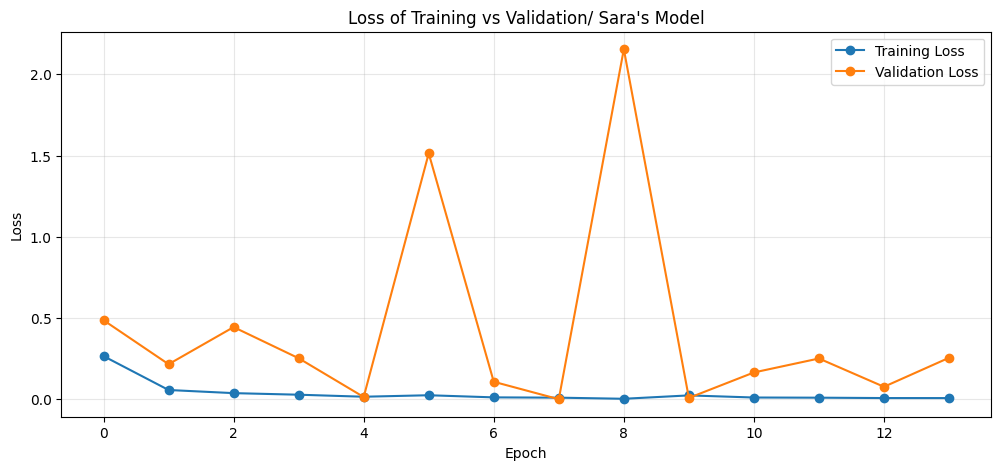

In [16]:
plt.figure(figsize=(12, 5))

plt.plot(history.history["accuracy"], marker="o", label="Training Accuracy")
plt.plot(history.history["val_accuracy"], marker="o", label="Validation Accuracy")

plt.title("Accuracy of Training vs Validation/ Sara's Model")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)

plt.savefig("Sara's_accuracy.png", dpi=150)
plt.show()


plt.figure(figsize=(12, 5))

plt.plot(history.history["loss"], marker="o", label="Training Loss")
plt.plot(history.history["val_loss"], marker="o", label="Validation Loss")

plt.title("Loss of Training vs Validation/ Sara's Model")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)

plt.savefig("Sara's_loss.png", dpi=150)
plt.show()

In [17]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

results_table = pd.DataFrame({
    "Metric": ["Test Loss", "Test Accuracy"],
    "Value": [f"{test_loss:.4f}", f"{test_accuracy * 100:.2f}%"]
})

print("=" * 50)
print("Test Results")
print("=" * 50)
print(results_table.to_string(index=False))
print("=" * 50)

Test Results
       Metric  Value
    Test Loss 0.0027
Test Accuracy 99.92%


In [18]:
student_name = "Sara"
model_filename = f"{student_name}_ucf11_model.h5"

model.save(model_filename)

print("Model saved as:", model_filename)

Model saved as: Sara_ucf11_model.h5


In [19]:
import sys
import subprocess

try:
    import yt_dlp
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "yt-dlp"])
    import yt_dlp


def get_video_stream(youtube_url):
    options = {
        "format": "best[ext=mp4]/best",
        "quiet": True
    }

    with yt_dlp.YoutubeDL(options) as ydl:
        video_info = ydl.extract_info(youtube_url, download=False)
        return video_info["url"]

def predict_video(video_source, max_frames=80):
    cap = cv2.VideoCapture(video_source)

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total_frames <= 0:
        cap.release()
        return None

    start_frame = int(total_frames * 0.20)
    end_frame = int(total_frames * 0.85)

    selected_indices = np.linspace(start_frame, end_frame, max_frames).astype(int)

    collected_frames = []

    for frame_idx in selected_indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
        ret, frame = cap.read()

        if not ret:
            continue

        frame = cv2.resize(frame, (IMG_WIDTH, IMG_HEIGHT))
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frame = frame.astype("float32") / 255.0
        collected_frames.append(frame)

    cap.release()

    if len(collected_frames) == 0:
        return None

    video_array = np.asarray(collected_frames)
    predictions = model.predict(video_array, verbose=0)

    avg_prediction = np.mean(predictions, axis=0)
    predicted_index = np.argmax(avg_prediction)

    predicted_class = TARGET_CLASSES[predicted_index]
    confidence = avg_prediction[predicted_index]

    return predicted_class, confidence


print("The Prediction Function Is Done Improved")

The Prediction Function Is Done Improved


In [26]:
# ****YOUTUBE VIDEOS TESTING****

youtube_tests = {
    "basketball": "https://www.youtube.com/watch?v=BWV1f3Y-J9U",
    "biking": "https://www.youtube.com/watch?v=YdEGStTJDQA",
    "tennis_swing": "https://www.youtube.com/shorts/Pgf5NUsDix0"
}

print("=" * 65)
print(f"{'Actual Video':<18} {'Predicted Class':<20} {'Confidence':>12}")
print("=" * 65)

for actual_class, youtube_link in youtube_tests.items():
    try:
        stream_link = get_video_stream(youtube_link)
        prediction = predict_video(stream_link)

        if prediction is not None:
            predicted_class, confidence = prediction
            print(f"{actual_class:<18} {predicted_class:<20} {confidence * 100:>11.2f}%")
        else:
            print(f"{actual_class:<18} {'Prediction Failed':<20} {'N/A':>12}")

    except Exception as e:
        print(f"{actual_class:<18} {'Error':<20} {'N/A':>12}")
        print("Reason:", e)

print("=" * 65)

Actual Video       Predicted Class        Confidence


basketball         basketball                 79.92%


biking             biking                     80.26%


tennis_swing       tennis_swing              100.00%
